In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt


# Добавить в референсы
# https://www.kaggle.com/code/saideepk0923/vol-prediction

In [2]:
data = pd.read_csv("../data/features_target.csv")

data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])
data.rename(columns = {'Unnamed: 0':'Date'}, inplace=True) 
data.set_index('Date', inplace = True)

data

,SP500,SP500 Log Returns,SP500 30 Day Volatility,SPX Put Call Ratio,SPX Put Volume,SPX Call Volume,Total SPX Options Volume,VIX,DJIA,NASDAQ,...,NASDAQ_log_returns,RUSSELL_log_returns,MSCI_World_log_returns,USD_Index_log_returns,Gold_log_returns,Oil_log_returns,SP500_put_log_change,SP500_call_log_change,SP500_total_opts_log_change,Consumer_Sentiment_log_change
Date,,,,,,,,,,,,,,,,,,,,,
2010-07-08,1070.25,0.009369,28.510976,1.12,280436.0,251021.0,531457.0,25.71,10138.99,2175.40,...,0.007350,0.013978,0.012148,0.000000,-0.002338,0.018862,-0.076998,-0.278034,-0.176999,0.000000
2010-07-09,1077.96,0.007178,28.462814,1.20,376805.0,315132.0,691937.0,24.98,10198.03,2196.45,...,0.009630,0.014660,0.006065,0.001550,0.011389,0.008183,0.295382,0.227455,0.263873,0.000000
2010-07-12,1078.75,0.000733,28.041079,1.49,421390.0,283127.0,704517.0,24.43,10216.27,2198.36,...,0.000869,-0.012502,0.000000,0.002974,-0.009217,-0.015231,0.111831,-0.107096,0.018018,0.000000
2010-07-13,1095.34,0.015262,28.157439,1.25,652349.0,519892.0,1172241.0,24.56,10363.02,2242.03,...,0.019670,0.033552,0.015906,-0.006673,0.012271,0.029327,0.437021,0.607726,0.509160,0.000000
2010-07-14,1095.17,-0.000155,28.338036,1.01,475499.0,469171.0,944670.0,24.89,10366.72,2249.84,...,0.003477,-0.004147,0.003690,-0.002514,-0.005371,-0.001816,-0.316215,-0.102654,-0.215837,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-30,2976.74,0.005035,47.065115,2.26,831789.0,368628.0,1200417.0,16.24,26916.83,7999.34,...,0.007492,0.001899,0.002066,0.002519,-0.022489,-0.033809,-0.428766,-0.404693,-0.421435,0.000000
2019-10-01,2940.25,-0.012334,46.781249,2.07,818005.0,395722.0,1213727.0,18.56,26573.04,7908.68,...,-0.011398,-0.019849,-0.009911,-0.002519,0.010872,-0.009100,-0.016710,0.070924,0.011027,0.024379
2019-10-02,2887.61,-0.018065,47.359805,1.82,1463102.0,804358.0,2267460.0,20.56,26078.62,7785.25,...,-0.015730,-0.009283,-0.017290,-0.001110,0.012613,-0.017503,0.581446,0.709332,0.624964,0.000000


In [3]:
thirty_day_data = data['SP500 30 Day Volatility']
VIX_data = data['VIX']
price_data = data['SP500']

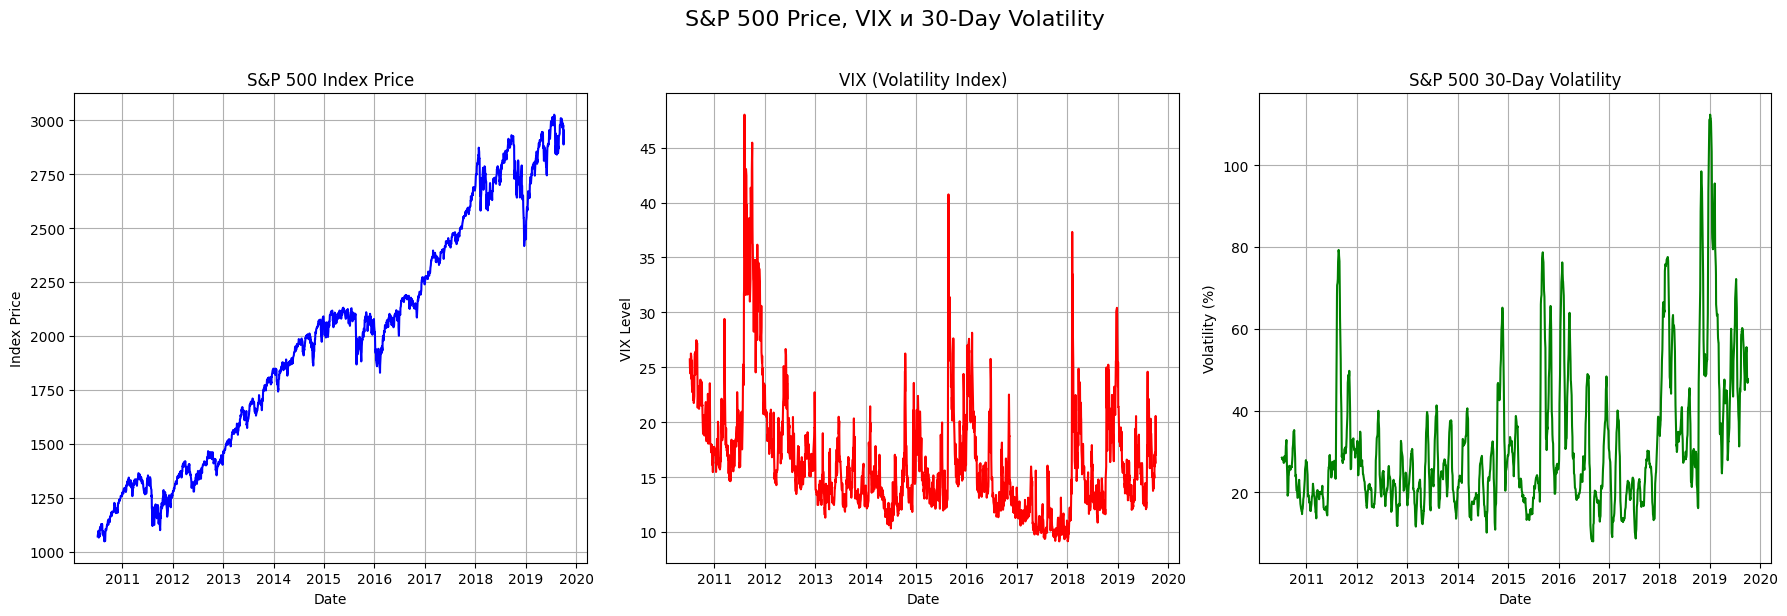

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

axes[0].plot(data.index, data['SP500'], color='blue')
axes[0].set_title('S&P 500 Index Price')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Index Price')
axes[0].grid(True)

axes[1].plot(data.index, data['VIX'], color='red')
axes[1].set_title('VIX (Volatility Index)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('VIX Level')
axes[1].grid(True)

axes[2].plot(data.index, data['SP500 30 Day Volatility'], color='green')
axes[2].set_title('S&P 500 30-Day Volatility')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Volatility (%)')
axes[2].grid(True)

plt.suptitle('S&P 500 Price, VIX и 30-Day Volatility', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

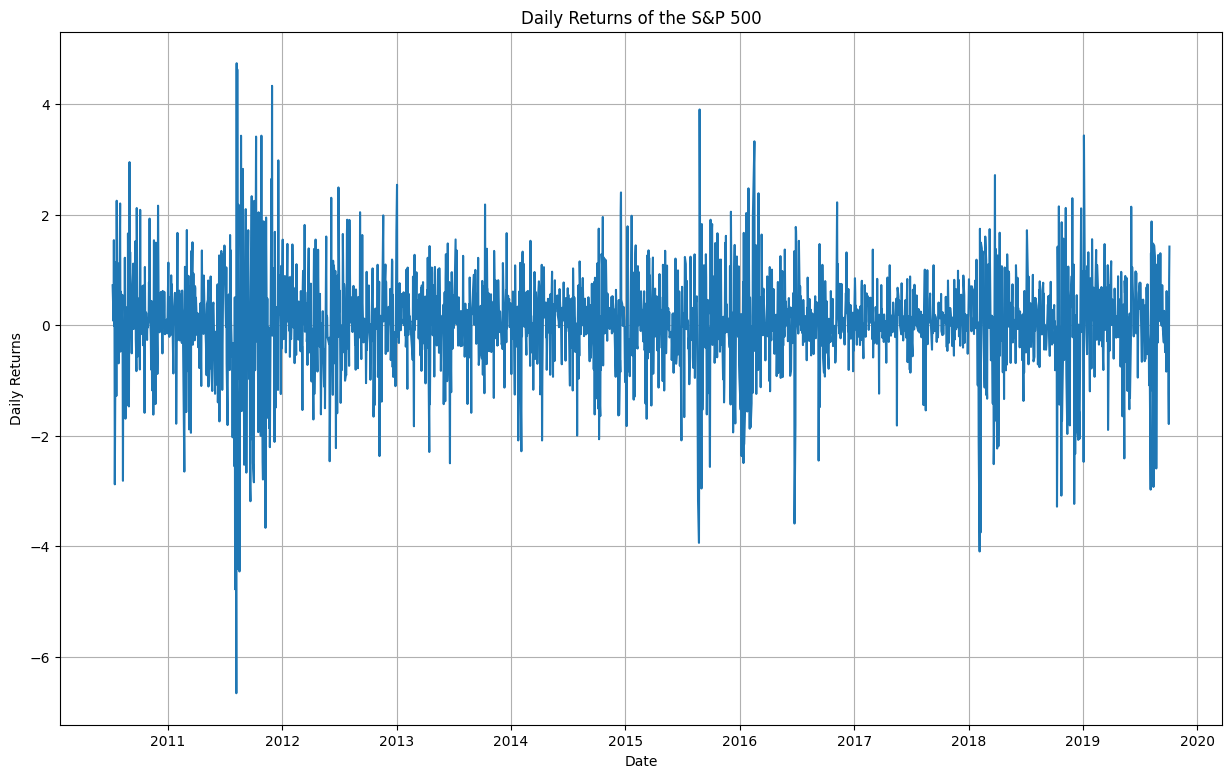

In [5]:
returns = 100 * price_data.pct_change().dropna()
returns = returns.drop(returns[returns == 0].index)

plt.figure(figsize=(15,9))
plt.grid()
plt.plot(returns)
plt.title("Daily Returns of the S&P 500")
plt.xlabel("Date")
plt.ylabel("Daily Returns")
plt.show()

In [6]:
#volatility = std(returns)
daily_vol = returns.std()
#21 trading days per month
monthly_vol = math.sqrt(21) * daily_vol
#252 trading days per year
yearly_vol = math.sqrt(252) * daily_vol
print("Daily Volatility: " + str(daily_vol))
print("Monthly Volatility: " + str(monthly_vol))
print("Yearly Volatility: " + str(yearly_vol))

Daily Volatility: 0.9155826488170592
Monthly Volatility: 4.195726793192343
Yearly Volatility: 14.534423960974351
